In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display
import matplotlib.pyplot as plt 

In [2]:
# (3 kübit, 3 klasik bit)
circuit = QuantumCircuit(3, 3)

In [3]:
# q0'ı |1> durumuna getirilir (Işınlanacak mesaj bu)
circuit.x(0) 
circuit.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>), clbits=())

Adım 1 ve 2: Durum ve Dolaşıklık


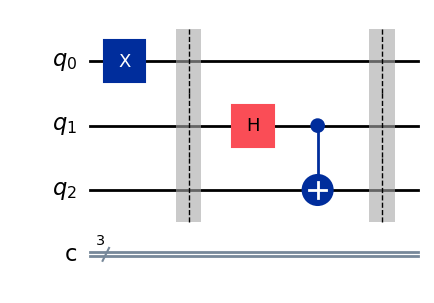

In [4]:
# Dolaşıklık (Entanglement) Oluşturma
# q1 ve q2 arasında Bell çifti oluşturuyoruz
circuit.h(1)
circuit.cx(1, 2)
circuit.barrier()

print("Adım 1 ve 2: Durum ve Dolaşıklık")
display(circuit.draw(output='mpl'))

Adım 3: Bell İşlemi


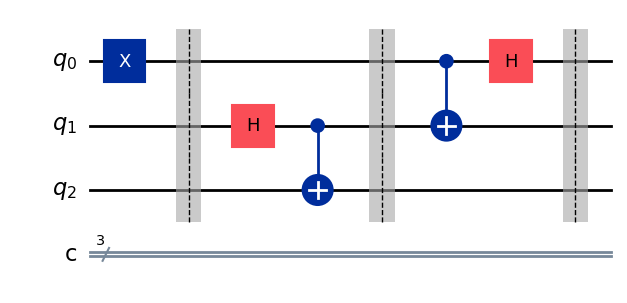

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>), clbits=())

In [5]:
# Bell Ölçümü
# q0 ve q1'i işleme sokup ölçüme hazırlıyoruz
circuit.cx(0, 1)
circuit.h(0)
circuit.barrier()

# q0 ve q1'i ölçüyoruz (Sonuçlar c0 ve c1'e yazılır)
print("Adım 3: Bell İşlemi")
display(circuit.draw(output='mpl'))

circuit.measure([0, 1], [0, 1])
circuit.barrier()

Adım 4: Düzeltme ve Son Ölçüm (Tam Devre)


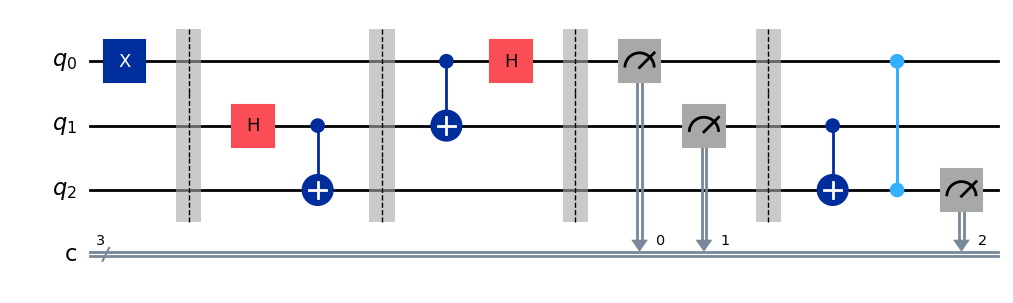

In [6]:
# Düzeltme Operasyonları (Teleportasyonun Sonu)
# Simülatörde ölçüm sonrası kapılar, ölçülen duruma göre davranır.
circuit.cx(1, 2) # Eğer q1 '1' çıktıysa q2'yi çevir (X)
circuit.cz(0, 2) # Eğer q0 '1' çıktıysa q2'ye faz uygula (Z)

# Işınlama başarılı mı diye q2'yi ölçüyoruz (c2'ye yaz)
circuit.measure([2], [2])

print("Adım 4: Düzeltme ve Son Ölçüm (Tam Devre)")
display(circuit.draw(output='mpl'))

In [8]:
# SİMÜLASYON
simulator = AerSimulator()
t_circ = transpile(circuit, simulator)

In [9]:
result = simulator.run(t_circ, shots=1024).result()
counts = result.get_counts()


Simülasyon Sonuçları: {'101': 255, '111': 276, '110': 237, '100': 256}


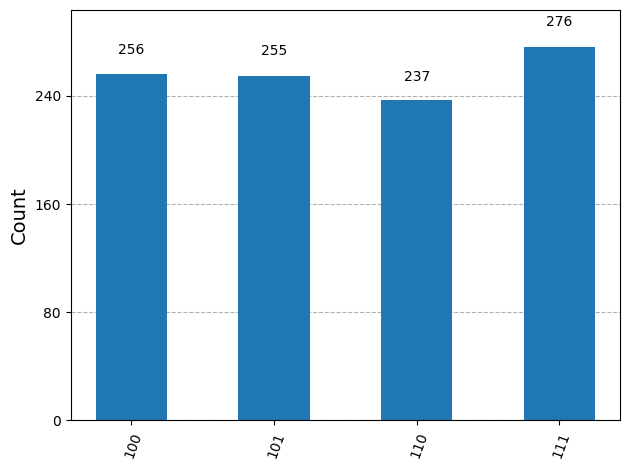

In [10]:
print("\nSimülasyon Sonuçları:", counts)
display(plot_histogram(counts))